## Part 1: Embedding and Positional Encoding

In [218]:
import torch
import torch.nn as nn
from torch import math

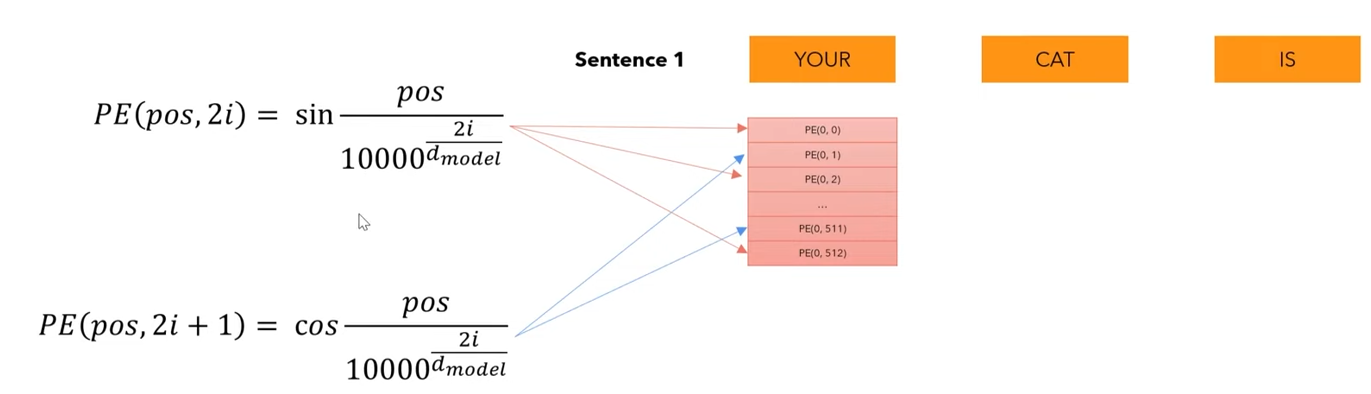

In [219]:
class InputEmbeddings(nn.Module):
    def __init__(self, d_model:int, vocab_size: int):
        super().__init__()
        self.d_model = d_model
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=d_model
        )

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.d_model)

class PositionalEncoding(nn.Module):
    # add PE to the input embedding d_model
    def __init__(self, d_model: int, seq_len: int, dropout: float) -> None:
        # seq_len of the sentence
        # dropout make model less overfit
        super().__init__()
        self.d_model = d_model
        self.seq_len = seq_len
        self.dropout = nn.Dropout(dropout)

        # add positional encoding matrix
        pe = torch.zeros(seq_len, d_model)

        # create position from 0 to seq_len-1 using arange(start, end, step)
        position = torch.arange(0, seq_len).unsqueeze(1) # shape (seq_len, 1)

        # log transformation from 10000^(2i / d_model)
        # to e^(2i/d_model * ln(10000))
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000)/d_model)) # shape (d_model / 2)

        # apply positional encoding to even/odd embedding collumns (not row)
        #? start:stop:step - 0::2 mean start at 0 increase with step of 2, 1::2 is the same but start with 1
        pe[:, 0::2] = torch.sin(position * div_term) # apply PE to every EVEN sequence position
        pe[:, 1::2] = torch.cos(position * div_term) # apply PE to every ODD sequence position

        # add PE to Batch, the first dim out of 3 dim is consider batch dimension
        # PE shape [1, seq_len, d_model] can be put into input batches now
        pe = pe.unsqueeze(0)

        # make sure PE is not model params, not getting update
        self.register_buffer('pe', pe) # can use to call self.pe


    def forward(self, x):
        """

        Args:
            x (torch.Tensor): input tensor (batch_size, seq_len, d_model)

        Returns:
            torch.Tensor output with Positional Encoding added
        """

        # self.pe is [1, seq_len, d_model] and x is [batch_len, seq_len, d_model]
        x = x + (self.pe[:, :x.shape[1], :]).requires_grad_(False) # type: ignore
        return self.dropout(x)

In [220]:
print("\n--- Testing Modules ---")

# Parameters
vocab_size_test = 1000  # Example vocabulary size
d_model_test = 512    # Must match d_model used in PositionalEncoding
max_len_test = 100     # Max sequence length for PE
dropout_test = 0.1

# Dummy input (batch_size=2, sequence_length=10)
batch_size_test = 2
seq_len_test = 10
dummy_token_ids = torch.randint(0, vocab_size_test, (batch_size_test, seq_len_test))
print(f"Dummy Token IDs shape: {dummy_token_ids.shape}")

# Instantiate modules
embedding_layer = InputEmbeddings(d_model_test, vocab_size_test)
positional_encoding_layer = PositionalEncoding(d_model_test, max_len_test, dropout_test)

# --- Test InputEmbeddings ---
embedding_output = embedding_layer(dummy_token_ids)
print(f"Output shape after InputEmbeddings: {embedding_output.shape}") # Expected: [2, 10, 512]
assert embedding_output.shape == (batch_size_test, seq_len_test, d_model_test)
print("InputEmbeddings test passed.")

# --- Test PositionalEncoding ---
# Note: PE layer takes embeddings as input
final_output = positional_encoding_layer(embedding_output)
print(f"Output shape after PositionalEncoding: {final_output.shape}") # Expected: [2, 10, 512]
assert final_output.shape == (batch_size_test, seq_len_test, d_model_test)
print("PositionalEncoding test passed.")

# Check if positional encodings were added (output should not be same as input)
assert not torch.equal(embedding_output, final_output), "Positional encoding was not added!"
print("Output differs from input after PE (as expected).")


--- Testing Modules ---
Dummy Token IDs shape: torch.Size([2, 10])
Output shape after InputEmbeddings: torch.Size([2, 10, 512])
InputEmbeddings test passed.
Output shape after PositionalEncoding: torch.Size([2, 10, 512])
PositionalEncoding test passed.
Output differs from input after PE (as expected).


## Practice Part 1

In [221]:
import torch
from torch import nn
import math

### Tokenizer -> Embedding * m_dim -> PE 

In [222]:
class InputEmbedding(nn.Module):
    """
        Apply Embedding for input Tokens
    """
    def __init__(self, vocab_size, m_dim):
        super().__init__()
        self.m_dim = m_dim
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size, # size of embed vocab/corpus/dictionary
            embedding_dim=m_dim, # word's embedding dimension
        )

    def forward(self, x):
        return self.embedding(x) * math.sqrt(self.m_dim)

In [223]:
class PositionalEncoding(nn.Module):
    def __init__(self, seq_len, m_dim, dropout=0.1) -> None:
        super().__init__()
        self.seq_len = seq_len
        self.m_dim = m_dim
        self.dropout = nn.Dropout(dropout)

        #? Global Value holder for entire PE matrix
        # create empty array for Positional Matrix called positional encoding or pe for short
        pe = torch.zeros(self.seq_len, self.m_dim, dtype=torch.float) # (seq_len, m_dim)

        #? Local value holder for even/odd position by sequence len
        # initialize even/odd position that get inserted into Positional Matrix
        position = torch.arange(0, seq_len).unsqueeze(1) # shape: (seq_len, 1)
        print("pos:", position.shape)
        # 10000^(2i/m_dim) -> e^(2i/m_dim * ln(10000))
        div_term = torch.exp(torch.arange(0, m_dim, 2).float() * (-math.log(10000)/m_dim)) # shape: 512/2

        #? add even/odd PE [seq_len, m_dim]
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # add batch dimension to merge with input X
        pe = pe.unsqueeze(0) #? [1 batch, seq_len, m_dim]

        # add register buffer to avoid value update
        self.register_buffer('pe', pe)


    def forward(self, x):
        print('X:', x.shape)
        print('pe:',self.pe.shape)
        x = x + self.pe[:, :x.shape[1], :] # type: ignore
        return self.dropout(x)

In [224]:
vocab_size = 1000
m_dim = 512
seq_len = 10
batch_size = 2

tokens = torch.randint(0, vocab_size, (batch_size, seq_len))
print(tokens.shape)

input_embed = InputEmbedding(vocab_size, m_dim)
out_embed = input_embed(tokens)
print(out_embed.shape)
pe = PositionalEncoding(seq_len, m_dim, dropout=0.1)
out_pe = pe(out_embed)
print(out_pe.shape)

torch.Size([2, 10])
torch.Size([2, 10, 512])
pos: torch.Size([10, 1])
X: torch.Size([2, 10, 512])
pe: torch.Size([1, 10, 512])
torch.Size([2, 10, 512])


## Part 2: Scaled Dot-Product Attention
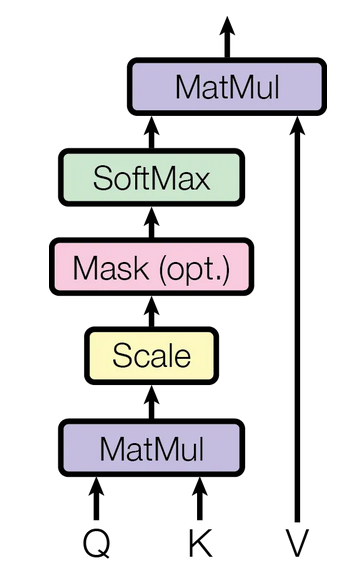 

Softmax shape is a matrix by k and v sequence length `(batch, num_head, seq_k, seq_v)`. Because 1 is col (K.T) and 1 is row (Note shape K and V is similar to it doesn't matter :)

Note: Before multiply by v, softmax/attention_score have shape `(batch, num_head, seq_k, d_k)`

<img src="softm.png" width="444" height="auto">

In [225]:
# Initialize QKV (bottleneck HOW TO INITIALIZE ??) -> just create the func 1st, initiate later, don't overthink it
def scaled_dot_product_attention(query: torch.Tensor, key: torch.Tensor, value: torch.Tensor, mask: torch.Tensor = None, dropout: torch.float = 0.5): # type: ignore
    """
    Compute Attention Score
    (Q,K,V) = torch.softmax(QK^T / math.sqrt(d_k)) * V
    d_k = d_model // num_heads

    Args:
        query (torch.Tensor): Query tensor, shape (batch_size, num_heads, seq_len_q, d_k)
        key (torch.Tensor): Key tensor, shape (batch_size, num_heads, seq_len_k, d_k)
        value (torch.Tensor): Value tensor, shape (batch_size, num_heads, seq_len_v, d_v)
                                Note: seq_len_k and seq_len_v are typically the same.
        mask (torch.Tensor, optional): Mask tensor, shape broadcastable to
                                    (batch_size, num_heads, seq_len_q, seq_len_k).
                                    Positions with True or 1 will be masked (set to -inf). Defaults to None.
        dropout (nn.Dropout, optional): Dropout layer to apply to attention weights. Defaults to None.

    Returns:
        torch.Tensor: The output tensor after attention, shape (batch_size, num_heads, seq_len_q, d_v)
        torch.Tensor: The attention weights, shape (batch_size, num_heads, seq_len_q, seq_len_k)

    2 Main Question:
    Why tranpose(-2, -1) -> bc only the last 2 dim are calculatable ie. seq_len_q and d_k
    How to apply mask
    """

    # model embedding dimension
    d_model = query.shape[-1] # d_k = d_model // num_heads
    print('query_shape:', query.shape)
    # transpose because we only use (seq_len, d_k) for multiply dimension, since we can't just .T, it would transpose the whole matrix
    # Note: tranpose mean swapping row with column, thus we swap d_k and seq_len position
    key = key.transpose(-2, -1) #? k transpose
    print('key_transpose_shape:', key.shape)
    print('query @ key shape:', (query @ key).shape)

    #? MatMul + Scale -> calc Raw Attention Score for each query i and key j
    attn_score = ((query @ key) / math.sqrt(d_model)) # shape [batch, num_heads, seq_len, d_model]
    print('attn_score:', attn_score.shape)

    # If mask == True. Apply Mask (-inf) as zero padding
    # apply mask to ensure the decoder model only use the previous token, not the future token in training
    if mask is not None:
        attn_score = attn_score.masked_fill(mask == True, float('-inf'))

    #? SoftMax - calc probability distribution (attention/relationship) between K & V across K dimension (use dim=-1)
    # This mean, the attn_score matrix will reflect attention score across column K with V as Row.
    # intput (batch_size, num_heads, seq_len_q, dim_k)
    # output (batch_size, num_heads, seq_len_q, seq_len_k)
    attn_score = torch.softmax(attn_score, dim=-1) #? dim=-1 mean apply softmax along d_k (head's embedding)
    print('softmax shape:', attn_score.shape)

    if dropout is not None:
        attn_score = dropout(attn_score)

    #? Scaled Dot-Product Attention - attention between Q,K and V
    # output shape - (batch_size, num_heads, seq_len_v, d_v)
    output = attn_score @ value

    return output, attn_score


# Example shapes (adjust as needed)
batch, num_heads, seq_q, seq_k, d_k, d_v = 2, 8, 10, 10, 64, 64
query = torch.randn(batch, num_heads, seq_q, d_k)
key = torch.randn(batch, num_heads, seq_k, d_k)
value = torch.randn(batch, num_heads, seq_k, d_v)
mask_size = seq_q
mask = torch.tril(torch.ones(seq_q, seq_q))  # Causal mask example
dropout = nn.Dropout(0.1)

output, weights = scaled_dot_product_attention(query, key, value, mask=mask, dropout=dropout) # type: ignore
print("Output shape:", output.shape)  # Should be [2, 8, 10, 64]
print("Weights shape:", weights.shape)  # Should be [2, 8, 10, 10]

query_shape: torch.Size([2, 8, 10, 64])
key_transpose_shape: torch.Size([2, 8, 64, 10])
query @ key shape: torch.Size([2, 8, 10, 10])
attn_score: torch.Size([2, 8, 10, 10])
softmax shape: torch.Size([2, 8, 10, 10])
Output shape: torch.Size([2, 8, 10, 64])
Weights shape: torch.Size([2, 8, 10, 10])


### Scaled Dot-Product Test

In [226]:
# --- Unit Testing / Verification ---
print("\n--- Testing Scaled Dot-Product Attention ---")

# Parameters (Example)
batch_size_test = 2
num_heads_test = 8 # Number of attention heads (will be relevant in Part 3)
seq_len_q_test = 5 # Sequence length for queries
seq_len_k_test = 7 # Sequence length for keys/values
d_k_test = 64 // num_heads_test # Dimension of keys/queries per head
d_v_test = 64 // num_heads_test # Dimension of values per head
d_model_test = 64 # Total model dimension (d_k * num_heads)

# Dummy tensors
# Note the shape: (batch_size, num_heads, seq_len, dim_per_head)
dummy_q = torch.randn(batch_size_test, num_heads_test, seq_len_q_test, d_k_test)
dummy_k = torch.randn(batch_size_test, num_heads_test, seq_len_k_test, d_k_test)
dummy_v = torch.randn(batch_size_test, num_heads_test, seq_len_k_test, d_v_test) # seq_len_k == seq_len_v

print(f"Dummy Q shape: {dummy_q.shape}")
print(f"Dummy K shape: {dummy_k.shape}")
print(f"Dummy V shape: {dummy_v.shape}")

# --- Test without mask ---
print("\nTesting without mask:")
output_no_mask, weights_no_mask = scaled_dot_product_attention(dummy_q, dummy_k, dummy_v)
print(f"Output shape (no mask): {output_no_mask.shape}")       # Expected: [2, 8, 5, 8] (batch, heads, seq_q, dv)
print(f"Weights shape (no mask): {weights_no_mask.shape}")     # Expected: [2, 8, 5, 7] (batch, heads, seq_q, seq_k)
assert output_no_mask.shape == (batch_size_test, num_heads_test, seq_len_q_test, d_v_test)
assert weights_no_mask.shape == (batch_size_test, num_heads_test, seq_len_q_test, seq_len_k_test)
# Check if weights sum to 1 (approximately due to float precision)
print('weight sum:', weights_no_mask.sum(dim=-1)[:1])
assert torch.allclose(weights_no_mask.sum(dim=-1), torch.ones_like(weights_no_mask.sum(dim=-1))), "Weights don't sum to 1"
print("Test without mask passed.")

# --- Test with a simple look-ahead mask (for decoder self-attention) ---
# Create a mask for the query sequence length (seq_len_q_test = 5)
# Mask should be (seq_len_q, seq_len_k). Here seq_q=seq_k=5 for self-attention mask
mask_size = seq_len_q_test
# Create an upper triangular matrix (True above the diagonal)
look_ahead_mask = torch.triu(torch.ones(mask_size, mask_size), diagonal=1).bool()
# Expand mask to match attention score shape (batch_size, num_heads, seq_len_q, seq_len_k)
# We can use broadcasting: Unsqueeze for batch and head dimensions.
# Mask shape needs to be compatible: (1, 1, seq_len_q, seq_len_k) or similar
dummy_mask = look_ahead_mask.unsqueeze(0).unsqueeze(0) # Shape: [1, 1, 5, 5]

# Adjust dummy K/V seq len to match Q seq len for self-attention mask test
dummy_k_masked = torch.randn(batch_size_test, num_heads_test, seq_len_q_test, d_k_test)
dummy_v_masked = torch.randn(batch_size_test, num_heads_test, seq_len_q_test, d_v_test)

print("\nTesting with look-ahead mask:")
print(f"Look-ahead mask shape: {dummy_mask.shape}")
print("Mask (True means masked):")
print(look_ahead_mask) # Show the basic mask structure

output_masked, weights_masked = scaled_dot_product_attention(dummy_q, dummy_k_masked, dummy_v_masked, mask=dummy_mask)
print(f"Output shape (masked): {output_masked.shape}")   # Expected: [2, 8, 5, 8]
print(f"Weights shape (masked): {weights_masked.shape}") # Expected: [2, 8, 5, 5]
assert output_masked.shape == (batch_size_test, num_heads_test, seq_len_q_test, d_v_test)
assert weights_masked.shape == (batch_size_test, num_heads_test, seq_len_q_test, seq_len_q_test) # seq_k adjusted
# Check if masked weights are zero
masked_positions_weights = weights_masked.masked_select(dummy_mask)
assert torch.all(masked_positions_weights == 0), "Masked positions have non-zero weights!"
# Check if non-masked weights sum to 1
# Note: Need to be careful here, sum across seq_k dim
assert torch.allclose(weights_masked.sum(dim=-1), torch.ones_like(weights_masked.sum(dim=-1))), "Weights don't sum to 1"
print("Test with mask passed.")


--- Testing Scaled Dot-Product Attention ---
Dummy Q shape: torch.Size([2, 8, 5, 8])
Dummy K shape: torch.Size([2, 8, 7, 8])
Dummy V shape: torch.Size([2, 8, 7, 8])

Testing without mask:
query_shape: torch.Size([2, 8, 5, 8])
key_transpose_shape: torch.Size([2, 8, 8, 7])
query @ key shape: torch.Size([2, 8, 5, 7])
attn_score: torch.Size([2, 8, 5, 7])
softmax shape: torch.Size([2, 8, 5, 7])
Output shape (no mask): torch.Size([2, 8, 5, 8])
Weights shape (no mask): torch.Size([2, 8, 5, 7])
weight sum: tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]]])
Test without mask passed.

Testing with look-ahead mask:
Look-ahead mask shape: torch

## Part 3: Multi-Head Attention (Parallel Scale Dot-Product)
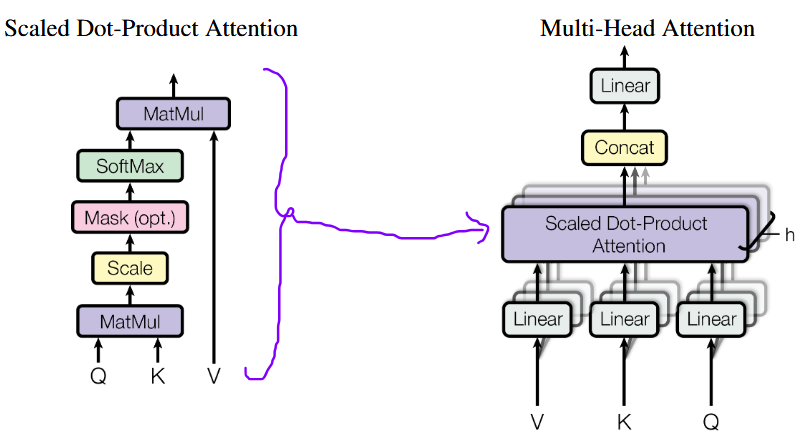

In [227]:
batch_size = 2
nhead = 8
dim = 4
sample_size = 3
q = torch.randn(batch_size, sample_size, nhead, dim) # batch, sample_per_batch, seq_len, model_dim
print(q.shape)
q = q.transpose(1, 2)
print(q.shape)
q = q.contiguous() # tensor are defracmented after transpose(), must use contiguous to use .view()
print(q.shape)


torch.Size([2, 3, 8, 4])
torch.Size([2, 8, 3, 4])
torch.Size([2, 8, 3, 4])


In [ ]:
class MultiHeadAttention(nn.Module):
    #? problem Project Linear for Q, K, V
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.5):
        """
        Args:
            d_model (int): Total dimension of the model.
            num_heads (int): Number of attention heads.
            dropout (float): Dropout probability.
        """
        super().__init__()
        assert d_model % num_heads == 0; "Model total Dimension must divided to number of attention head"

        # dim of each Attention Head
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # Initialize Projection for Q,K,V and O for output.
        # use W because attention are Weight
        self.W_k = nn.Linear(self.d_model, self.d_model) # this mean W_i have shape self.d_model x self.d_k
        self.W_q = nn.Linear(self.d_model, self.d_model)
        self.W_v = nn.Linear(self.d_model, self.d_model) # suppose d_k == d_v

        # Apply Linear to the final layer
        self.W_o = nn.Linear(self.d_model, self.d_model) # self.d_model ~ d_k * num_head

        # apply drop out
        self.dropout = nn.Dropout(dropout)
        self.attention_weights = None # use for visualize later (optional)


    def forward(self, q: torch.Tensor, k: torch.Tensor, v: torch.Tensor, mask: torch.tensor = None):
        """
        Forward pass for Multi-Head Attention.

        Args:
            query (torch.Tensor): Query tensor, shape (batch_size, seq_len_q, d_model)
            key (torch.Tensor): Key tensor, shape (batch_size, seq_len_k, d_model)
            value (torch.Tensor): Value tensor, shape (batch_size, seq_len_v, d_model)
                                    Note: seq_len_k and seq_len_v are typically the same.
            mask (torch.Tensor, optional): Mask tensor, typically for padding or look-ahead.
                                            Shape needs to be broadcastable for attention scores.
                                            Example shapes: (batch_size, 1, 1, seq_len_k) for padding mask,
                                                            (1, 1, seq_len_q, seq_len_k) for look-ahead mask.

        Returns:
            torch.Tensor: Output tensor, shape (batch_size, seq_len_q, d_model)
        """

        # Apply Linear Projection
        query = self.W_q(q) # self.d_model, self.d_model
        key = self.W_k(k)
        value = self.W_v(v)

        batch_size = q.shape[0]
        print('query shape:', query.shape)
        print('key shape:', key.shape)
        print('value shape:', value.shape, '\n')

        # origin shape (batch_size, seq_len_q, d_model)
        #? reshape to (batch_size, num_heads, seq_len_q, d_k) to match scaled_dot_product_attention output dim
        query = query.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2) # .reshape() ~ .view() but view is faster
        key = key.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        value = value.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        # Apply Multi-head Attention from Above
        # output shape (batch_size, num_heads, seq_len_q, d_k)
        output, self.attention_weights = scaled_dot_product_attention(query, key, value, mask, self.dropout)

        #? Apply Forward() to concat all scale_dot_product(head_i)
        # Transpose scaled_dot_product_attention output shape to MultiHeadAttention shape
        # (batch_size, seq_len_q, num_heads, d_k)
        out = output.transpose(1, 2).contiguous()

        # concat mean merge 2 dim together, I use -1 to merge num_heads and seq_len (num_head * seq_len)
        out = out.view(batch_size, -1, self.d_model)

        #? Apply Final Linear to Output
        # input/out shape: (batch_size, seq_len_q, d_model)
        out = self.W_o(out)
        print('OUT shape:', output.shape)

        return out

In [229]:
# Apply Causal mask
# mask = torch.tril(torch.ones(batch_size, self.num_heads, seq_q, seq_q))

In [230]:
# --- Unit Testing / Verification ---
print("\n--- Testing Multi-Head Attention ---")

# Parameters
batch_size_test = 4
seq_len_test = 10 # Sequence length for Q, K, V (can differ for K/V if not self-attention)
d_model_test = 512
num_heads_test = 8
dropout_test = 0.1

# Create dummy input tensors
dummy_q = torch.randn(batch_size_test, seq_len_test, d_model_test)
dummy_k = torch.randn(batch_size_test, seq_len_test, d_model_test)
dummy_v = torch.randn(batch_size_test, seq_len_test, d_model_test)

# Create a dummy mask (e.g., padding mask for key/value sequence)
# Mask shape (batch_size, 1, 1, seq_len_k) -> True where padded
dummy_mask_mha = torch.zeros(batch_size_test, 1, 1, seq_len_test, dtype=torch.bool)
# Let's mask the last 2 positions for the first batch item, last 1 for the second
if batch_size_test >= 1:
    dummy_mask_mha[0, :, :, -2:] = True
if batch_size_test >= 2:
    dummy_mask_mha[1, :, :, -1:] = True
# Add more mask examples if batch_size_test > 2...

print(f"Dummy Q/K/V shape: {dummy_q.shape}") # Expected: [4, 10, 512]
print(f"Dummy Mask shape: {dummy_mask_mha.shape}") # Expected: [4, 1, 1, 10]

# Instantiate the module

mha_layer = MultiHeadAttention(d_model=d_model_test, num_heads=num_heads_test, dropout=dropout_test)

# Perform forward pass
output_mha = mha_layer(dummy_q, dummy_k, dummy_v, mask=dummy_mask_mha)

# Check output shape
print(f"Output shape after MultiHeadAttention: {output_mha.shape}") # Expected: [4, 10, 512]
assert output_mha.shape == (batch_size_test, seq_len_test, d_model_test)

# Check stored attention weights shape (optional)
# Stored weights are from the scaled_dot_product_attention call
# Shape: (batch_size, num_heads, seq_len_q, seq_len_k)
print(f"Stored Attention Weights shape: {mha_layer.attention_weights.shape}") # Expected: [4, 8, 10, 10]
assert mha_layer.attention_weights.shape == (batch_size_test, num_heads_test, seq_len_test, seq_len_test)

print("MultiHeadAttention test passed.")


--- Testing Multi-Head Attention ---
Dummy Q/K/V shape: torch.Size([4, 10, 512])
Dummy Mask shape: torch.Size([4, 1, 1, 10])
query shape: torch.Size([4, 10, 512])
key shape: torch.Size([4, 10, 512])
value shape: torch.Size([4, 10, 512]) 

query_shape: torch.Size([4, 8, 10, 64])
key_transpose_shape: torch.Size([4, 8, 64, 10])
query @ key shape: torch.Size([4, 8, 10, 10])
attn_score: torch.Size([4, 8, 10, 10])
softmax shape: torch.Size([4, 8, 10, 10])
OUT shape: torch.Size([4, 8, 10, 64])
Output shape after MultiHeadAttention: torch.Size([4, 10, 512])
Stored Attention Weights shape: torch.Size([4, 8, 10, 10])
MultiHeadAttention test passed.


### Practice Multi-Head Attention

In [ ]:

import torch
from torch import nn

class MultiHeadAttention2(nn.Module):
    def __init__(self, num_heads: torch.Tensor, d_model: torch.Tensor, dropout: torch.float = 0.5):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must divided to num_heads"

        self.d_k = d_model // num_heads
        self.num_heads = num_heads
        self.d_model = d_model
        self.dropout = nn.Dropout(dropout)

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model) # h x d_v = d_model

        self.attention_weights = None # hold attn_weight from scale-dot product for visualizaton


    def forward(self, Q: torch.Tensor, K: torch.Tensor, V: torch.Tensor, mask: torch.Tensor):
        """calc multi-head attention for QKV

        Args:
            Q (torch.Tensor): query tensor, shape (batch_size, seq_len, d_model)
            K (torch.Tensor): query tensor, shape (batch_size, seq_len, d_model)
            V (torch.Tensor): query tensor, shape (batch_size, seq_len, d_model)
            mask (torch.Tensor): mask matrix between K and V matrix -> output is a matrix as well, shape (batch_size, seq_len, d_model, d_model)
        """
        Q = self.W_q(Q)
        K = self.W_k(K)
        V = self.W_v(V)
        batch_size = Q.shape[0] # or Q.size(1)

        #? Seperate QKV Matrix into multiple num_heads across all batch, seq_len and model dim (Seperate Matrix by group)
        Q = Q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2) # use view for faster processing
        K = K.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        V = V.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2) # suppose d_k = d_v

        #? Calc and Combine Attention Head
        # reshape to (batch_size, num_head, seq_len, d_model), num_head bc of the parallel law, from outside to inside.
        # reshape have 2 benefit, 1st is to match the function dimension, 2nd is for faster dot product parallel processing/calculation
        output, self.attention_weights = scaled_dot_product_attention(Q,K,V,mask=mask)
        output = output.transpose(1,2).contiguous() # transpose back to (batch_size, seq_len, num_heads, d_k)

        #? Concatinate num_heads and seq_len after dot prod calculation
        output = output.view(batch_size, -1, self.d_model) #? Group Head along with model dim, bc previously we seperate head by model dim
        print('Out shape:', output.shape)
        #? Linear Project to the last output
        output = self.W_o(output)

        return output


In [245]:
# --- Unit Testing / Verification ---
print("\n--- Testing Multi-Head Attention ---")

# Parameters
batch_size_test = 4
seq_len_test = 10 # Sequence length for Q, K, V (can differ for K/V if not self-attention)
d_model_test = 512
num_heads_test = 8
dropout_test = 0.1

# Create dummy input tensors
dummy_q = torch.randn(batch_size_test, seq_len_test, d_model_test)
dummy_k = torch.randn(batch_size_test, seq_len_test, d_model_test)
dummy_v = torch.randn(batch_size_test, seq_len_test, d_model_test)

# Create a dummy mask (e.g., padding mask for key/value sequence)
# Mask shape (batch_size, 1, 1, seq_len_k) -> True where padded
dummy_mask_mha = torch.zeros(batch_size_test, 1, 1, seq_len_test, dtype=torch.bool)
# Let's mask the last 2 positions for the first batch item, last 1 for the second
if batch_size_test >= 1:
    dummy_mask_mha[0, :, :, -2:] = True
if batch_size_test >= 2:
    dummy_mask_mha[1, :, :, -1:] = True
# Add more mask examples if batch_size_test > 2...

print(f"Dummy Q/K/V shape: {dummy_q.shape}") # Expected: [4, 10, 512]
print(f"Dummy Mask shape: {dummy_mask_mha.shape}") # Expected: [4, 1, 1, 10]

# Instantiate the module

mha_layer = MultiHeadAttention2(d_model=d_model_test, num_heads=num_heads_test, dropout=dropout_test)

# Perform forward pass
output_mha = mha_layer(dummy_q, dummy_k, dummy_v, mask=dummy_mask_mha)

# Check output shape
print(f"Output shape after MultiHeadAttention2: {output_mha.shape}") # Expected: [4, 10, 512]
assert output_mha.shape == (batch_size_test, seq_len_test, d_model_test)


--- Testing Multi-Head Attention ---
Dummy Q/K/V shape: torch.Size([4, 10, 512])
Dummy Mask shape: torch.Size([4, 1, 1, 10])
query_shape: torch.Size([4, 8, 10, 64])
key_transpose_shape: torch.Size([4, 8, 64, 10])
query @ key shape: torch.Size([4, 8, 10, 10])
attn_score: torch.Size([4, 8, 10, 10])
softmax shape: torch.Size([4, 8, 10, 10])
Out shape: torch.Size([4, 10, 512])
Output shape after MultiHeadAttention2: torch.Size([4, 10, 512])


## Layers Norm
`LayerNorm(x + Sublayer(x))` - layer normalization apply to each SubLayer(x)
